In [51]:
import pandas as pd
import numpy as np

wesad=pd.read_csv("wesad_60s_features_with_labels.csv")
print(wesad.shape)


import pandas as pd 
import numpy as np
examstress=pd.read_csv("data.csv")
examstress.shape

(764, 24)


(7370, 23)

In [52]:
wesad=wesad.drop(columns=["subject"])
wesad["labels"]=wesad["label"]
wesad.drop(columns=["label"],inplace=True)

print(wesad.columns)
print(examstress.columns)

Index(['EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_median', 'EDA_slope',
       'EDA_motion_power', 'EDA_scr_count', 'HR_mean', 'HR_std', 'HR_min',
       'HR_max', 'HR_median', 'ACC_mean_mag', 'ACC_std_mag', 'ACC_energy',
       'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_median',
       'TEMP_slope', 'labels'],
      dtype='object')
Index(['EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_median', 'EDA_slope',
       'EDA_motion_power', 'EDA_scr_count', 'HR_mean', 'HR_std', 'HR_min',
       'HR_max', 'HR_median', 'ACC_mean_mag', 'ACC_std_mag', 'ACC_energy',
       'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_median',
       'TEMP_slope', 'Cluster'],
      dtype='object')


In [53]:
examstress.drop(columns=["Cluster"],inplace=True)
print(examstress.columns)
print(wesad.columns)

Index(['EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_median', 'EDA_slope',
       'EDA_motion_power', 'EDA_scr_count', 'HR_mean', 'HR_std', 'HR_min',
       'HR_max', 'HR_median', 'ACC_mean_mag', 'ACC_std_mag', 'ACC_energy',
       'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_median',
       'TEMP_slope'],
      dtype='object')
Index(['EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_median', 'EDA_slope',
       'EDA_motion_power', 'EDA_scr_count', 'HR_mean', 'HR_std', 'HR_min',
       'HR_max', 'HR_median', 'ACC_mean_mag', 'ACC_std_mag', 'ACC_energy',
       'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_median',
       'TEMP_slope', 'labels'],
      dtype='object')


In [54]:
wesad["labels"].value_counts()

labels
1    251
4    236
2    168
3    109
Name: count, dtype: int64

# **AMUSEMENT AND MEDITATION ARE NOT INDUCED IN EXAMINATION**

---
---


# **OVERVIEW OF THE DATA & TESTING ON MODEL FROM STUDENTS DATA**

---
---

Labels meaning (from WESAD paper)

0 → Undefined

1 → Baseline (neutral state)

2 → Stress (TSST)

3 → Amusement

4 → Meditation (only some subjects)/

In [55]:
wesad["labels"].value_counts()

wesadupdated=wesad.loc[wesad["labels"]!=3].copy()
wesadupdated=wesadupdated.loc[wesad["labels"]!=4].copy()
wesadupdated["labels"] = wesadupdated["labels"].astype(int)
print(wesadupdated.shape)
wesadupdated["labels"].value_counts()

(419, 23)


labels
1    251
2    168
Name: count, dtype: int64

In [56]:
wesadupdated["labels"] = wesadupdated["labels"].replace({1: 0, 2: 1})
wesadupdated["labels"].value_counts()

labels
0    251
1    168
Name: count, dtype: int64

In [57]:
from sklearn.model_selection import train_test_split
#HOLD OUT FOR FINAL EVALUATION

X_wesad = wesadupdated.drop(columns=['labels']).values
y_wesad = wesadupdated['labels'].values
X_train_labeled, X_holdout_labeled, y_train_labeled, y_holdout_labeled = train_test_split(X_wesad, y_wesad, test_size=0.2, random_state=42, stratify=y_wesad)

In [58]:
X_train_labeled.shape

(335, 22)

In [59]:
pd.Series(y_train_labeled).value_counts()

0    201
1    134
Name: count, dtype: int64

In [60]:
pd.Series(y_holdout_labeled).value_counts()

0    50
1    34
Name: count, dtype: int64

In [61]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Labeled Data (WESAD)
X_wesad = X_train_labeled
y_wesad = y_train_labeled

# Unlabeled Data (ExamStress)
X_exam_raw = examstress.values
unlabeled_indices = examstress.index.values 

# ==========================================
# 2. SCALING 
# ==========================================

# Split WESAD first to keep a clean test set
# We use this Test set to CALIBRATE our thresholds
X_train_labeled, X_test_labeled, y_train_labeled, y_test_labeled = train_test_split(
    X_wesad, y_wesad, test_size=0.2, random_state=42, stratify=y_wesad
)

scaler = StandardScaler()

# Fit ONLY on the original labeled training data
scaler.fit(X_train_labeled)

# Transform everything
X_train_labeled = scaler.transform(X_train_labeled)
X_test_labeled = scaler.transform(X_test_labeled)
X_unlabeled = scaler.transform(X_exam_raw) 

# ==========================================
# 2.5. AUTOMATED THRESHOLD OPTIMIZATION (RESEARCH VALIDITY)
# ==========================================
print("--- Optimizing Thresholds using WESAD Validation Set ---")

# 1. Train a baseline model
baseline_clf = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
baseline_clf.fit(X_train_labeled, y_train_labeled)

# 2. Get probabilities on the HELD-OUT test set
probs_test = baseline_clf.predict_proba(X_test_labeled)

# 3. Find thresholds that guarantee High Precision (Low Noise)
# We want to be 95% sure for Baseline, and at least 75% sure for Stress
desired_precision = {0: 0.95, 1: 0.75} 
optimal_thresholds = {}

# Loop through classes (0 and 1)
for class_label in [0, 1]:
    # Get precision-recall values for this class
    # y_test_labeled == class_label converts labels to binary (Is Class X or Not?)
    precisions, recalls, thresholds = precision_recall_curve(
        (y_test_labeled == class_label).astype(int), 
        probs_test[:, class_label]
    )
    
    # Find the lowest threshold that meets our precision requirement
    # We filter for indices where precision is high enough
    valid_indices = np.where(precisions[:-1] >= desired_precision[class_label])[0]
    
    if len(valid_indices) > 0:
        # Pick the threshold that gives highest recall while maintaining precision
        best_idx = valid_indices[0] # The first one that hits the target precision
        optimal_thresholds[class_label] = thresholds[best_idx]
    else:
        # Fallback if model is weak
        optimal_thresholds[class_label] = 0.90
        print(f"Warning: Model could not meet precision target for Class {class_label}. Defaulting to 0.90")

print(f"Calculated Optimal Thresholds: {optimal_thresholds}")
# Example Output: {0: 0.92, 1: 0.74} -> "We trust stress predictions at 74%, but baseline needs 92%"

# ==========================================
# 3. ITERATIVE SELF-TRAINING LOOP (UPDATED)
# ==========================================

max_iterations = 10 

# Initialize containers
X_current_train = X_train_labeled.copy()
y_current_train = y_train_labeled.copy()

X_remaining_unlabeled = X_unlabeled.copy()
indices_remaining = unlabeled_indices.copy()

final_pseudo_labels_map = {} 

print(f"\nStarting Self-Training...")
print(f"Initial Training Size: {len(X_current_train)}")

for i in range(max_iterations):
    
    # Train model on current set
    clf = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
    clf.fit(X_current_train, y_current_train)
    
    if len(X_remaining_unlabeled) == 0:
        break
        
    # Predict
    probs = clf.predict_proba(X_remaining_unlabeled)
    preds = clf.predict(X_remaining_unlabeled)
    max_probs = probs.max(axis=1)
    
    # --- DYNAMIC MASKING ---
    high_conf_mask = np.zeros(len(preds), dtype=bool)
    
    for class_label, thresh in optimal_thresholds.items():
        # Select rows where (Prediction == Class) AND (Confidence > Class_Threshold)
        class_mask = (preds == class_label) & (max_probs >= thresh)
        high_conf_mask = high_conf_mask | class_mask
    # -----------------------
    
    if not np.any(high_conf_mask):
        print(f"Iteration {i+1}: No predictions met dynamic thresholds. Stopping loop.")
        break
        
    # Extract high-confidence samples
    new_X = X_remaining_unlabeled[high_conf_mask]
    new_y = preds[high_conf_mask]
    added_indices = indices_remaining[high_conf_mask]
    
    # Store labels
    for idx, label in zip(added_indices, new_y):
        final_pseudo_labels_map[idx] = label
        
    # Add to training set
    X_current_train = np.vstack((X_current_train, new_X))
    y_current_train = np.concatenate((y_current_train, new_y))
    
    # Remove from "Remaining" pool
    X_remaining_unlabeled = X_remaining_unlabeled[~high_conf_mask]
    indices_remaining = indices_remaining[~high_conf_mask]
    
    # Print detailed stats for research logging
    unique, counts = np.unique(new_y, return_counts=True)
    dist = dict(zip(unique, counts))
    print(f"Iter {i+1}: Added {len(new_X)} samples. Distribution: {dist}")

# ==========================================
# 4. FINAL RESULTS & EXPORT
# ==========================================

final_model = LogisticRegression(solver='liblinear', class_weight='balanced')
final_model.fit(X_current_train, y_current_train)

# 1. Sanity Check
print("\n--- WESAD Test Set Report (Validation of Final Model) ---")
y_pred_test = final_model.predict(X_test_labeled)
print(classification_report(y_test_labeled, y_pred_test))

# 2. Export Labels
examstress['predicted_label'] = -1 
examstress['confidence_type'] = 'none' # Track which are High Conf vs Low Conf

# A. Fill High Confidence
for idx, label in final_pseudo_labels_map.items():
    examstress.at[idx, 'predicted_label'] = label
    examstress.at[idx, 'confidence_type'] = 'high_confidence_pseudo'

# B. Fill Low Confidence (Force Predict)
# Note: For research, you might want to exclude these rows, but we keep them for completeness
remaining_mask = examstress['predicted_label'] == -1

if remaining_mask.sum() > 0:
    print(f"\nForce predicting {remaining_mask.sum()} low-confidence samples...")
    X_remaining_raw = examstress.loc[remaining_mask].drop(columns=['predicted_label', 'confidence_type']).values
    X_remaining_scaled = scaler.transform(X_remaining_raw)
    
    low_conf_preds = final_model.predict(X_remaining_scaled)
    examstress.loc[remaining_mask, 'predicted_label'] = low_conf_preds
    examstress.loc[remaining_mask, 'confidence_type'] = 'low_confidence_forced'

print("\nFinal ExamStress Class Distribution:")
print(examstress['predicted_label'].value_counts())
print(examstress['confidence_type'].value_counts())

--- Optimizing Thresholds using WESAD Validation Set ---
Calculated Optimal Thresholds: {0: np.float64(0.6800524303855184), 1: np.float64(0.5440869277433947)}

Starting Self-Training...
Initial Training Size: 268
Iter 1: Added 7007 samples. Distribution: {np.int64(0): np.int64(6495), np.int64(1): np.int64(512)}
Iter 2: Added 296 samples. Distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(294)}
Iter 3: Added 67 samples. Distribution: {np.int64(1): np.int64(67)}

--- WESAD Test Set Report (Validation of Final Model) ---
              precision    recall  f1-score   support

           0       0.96      0.68      0.79        40
           1       0.67      0.96      0.79        27

    accuracy                           0.79        67
   macro avg       0.82      0.82      0.79        67
weighted avg       0.84      0.79      0.79        67


Final ExamStress Class Distribution:
predicted_label
0    6497
1     873
Name: count, dtype: int64
confidence_type
high_confidence_pseud

In [62]:
examstress["predicted_label"].value_counts()

predicted_label
0    6497
1     873
Name: count, dtype: int64

In [63]:
examstress.columns

Index(['EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max', 'EDA_median', 'EDA_slope',
       'EDA_motion_power', 'EDA_scr_count', 'HR_mean', 'HR_std', 'HR_min',
       'HR_max', 'HR_median', 'ACC_mean_mag', 'ACC_std_mag', 'ACC_energy',
       'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max', 'TEMP_median',
       'TEMP_slope', 'predicted_label', 'confidence_type'],
      dtype='object')

In [64]:
examstress.drop(columns=["confidence_type"],inplace=True)

In [65]:
print(examstress.shape)
print(wesad.shape)

(7370, 23)
(764, 23)


Dataset: (7370, 22), Labels: [6497  873]

=== None ===
   → LR | Acc=0.845 F1=0.840 AUC=0.951

     Confusion Matrix [None + LR]
[[37 13]
 [ 0 34]]
     TN  FP
     FN  TP

   → RF | Acc=0.833 F1=0.829 AUC=0.908

     Confusion Matrix [None + RF]
[[36 14]
 [ 0 34]]
     TN  FP
     FN  TP

   → HGBC | Acc=0.821 F1=0.819 AUC=0.932

     Confusion Matrix [None + HGBC]
[[35 15]
 [ 0 34]]
     TN  FP
     FN  TP

   → SVC | Acc=0.869 F1=0.845 AUC=0.922

     Confusion Matrix [None + SVC]
[[43  7]
 [ 4 30]]
     TN  FP
     FN  TP

   → MLP | Acc=0.869 F1=0.853 AUC=0.909

     Confusion Matrix [None + MLP]
[[41  9]
 [ 2 32]]
     TN  FP
     FN  TP


=== SMOTE ===
    Resampled -> (12994, 22)
   → LR | Acc=0.833 F1=0.829 AUC=0.951

     Confusion Matrix [SMOTE + LR]
[[36 14]
 [ 0 34]]
     TN  FP
     FN  TP

   → RF | Acc=0.833 F1=0.825 AUC=0.894

     Confusion Matrix [SMOTE + RF]
[[37 13]
 [ 1 33]]
     TN  FP
     FN  TP

   → HGBC | Acc=0.774 F1=0.782 AUC=0.924

     Confusion Matrix [

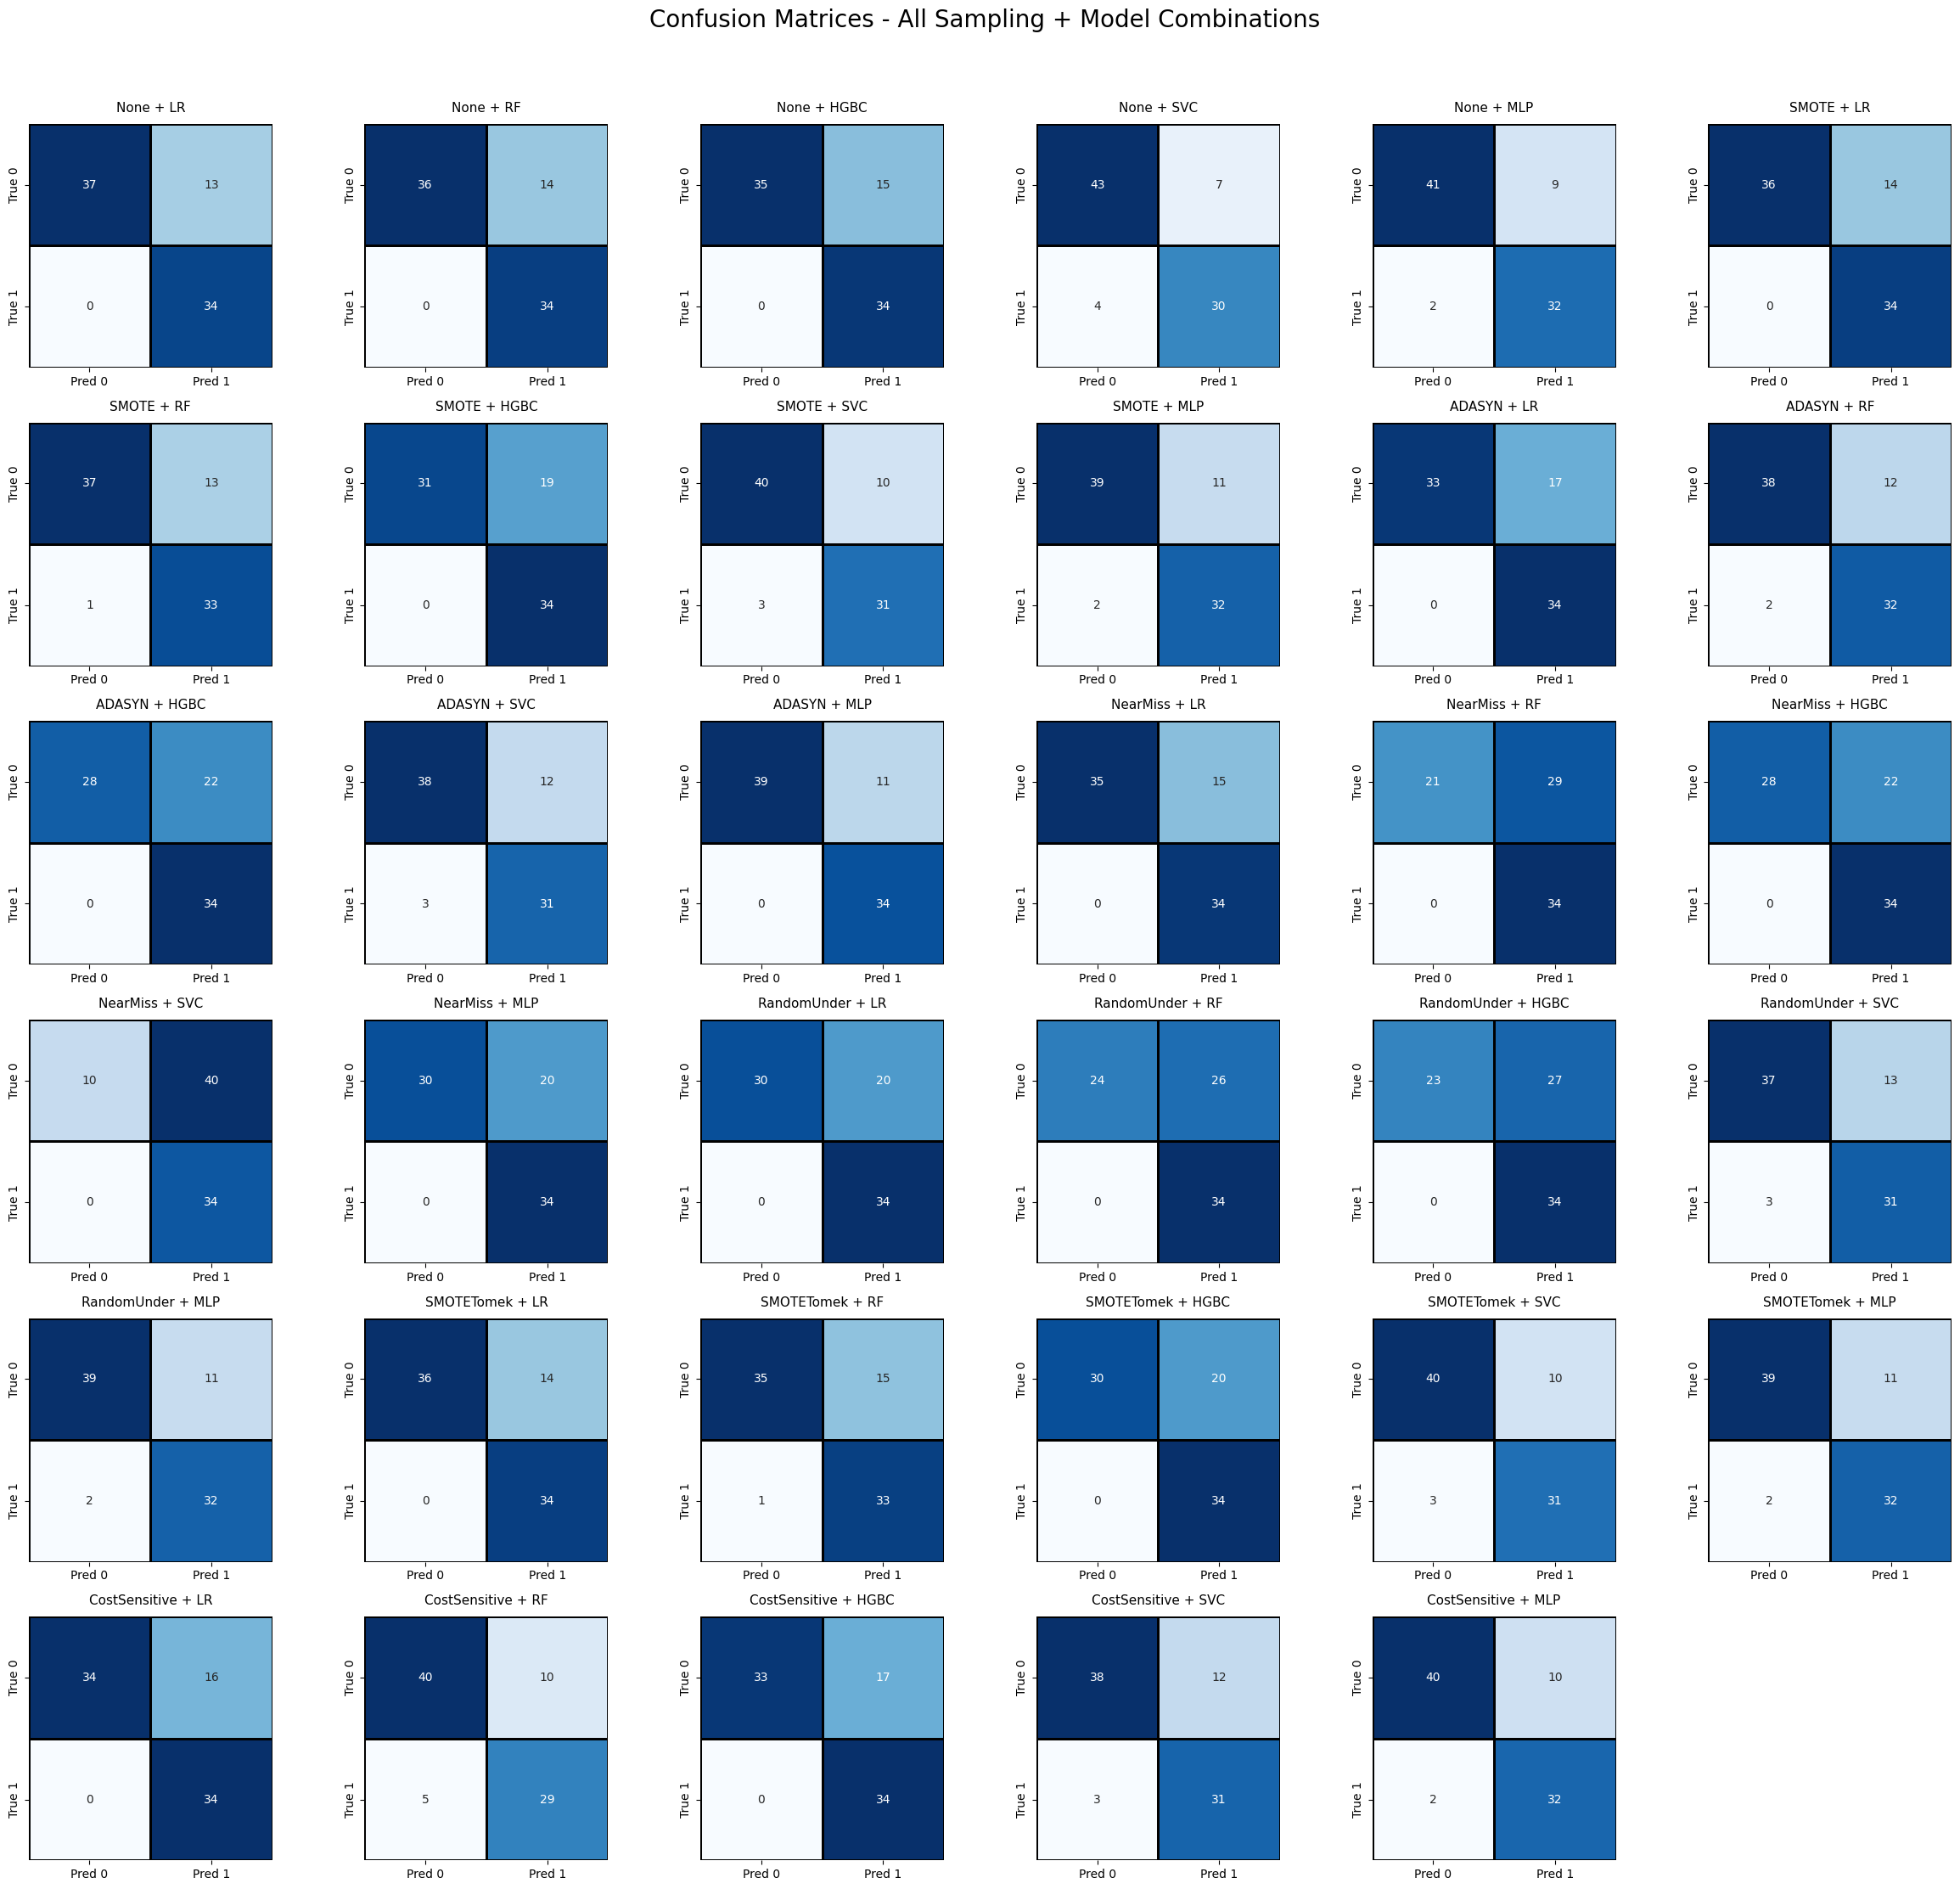

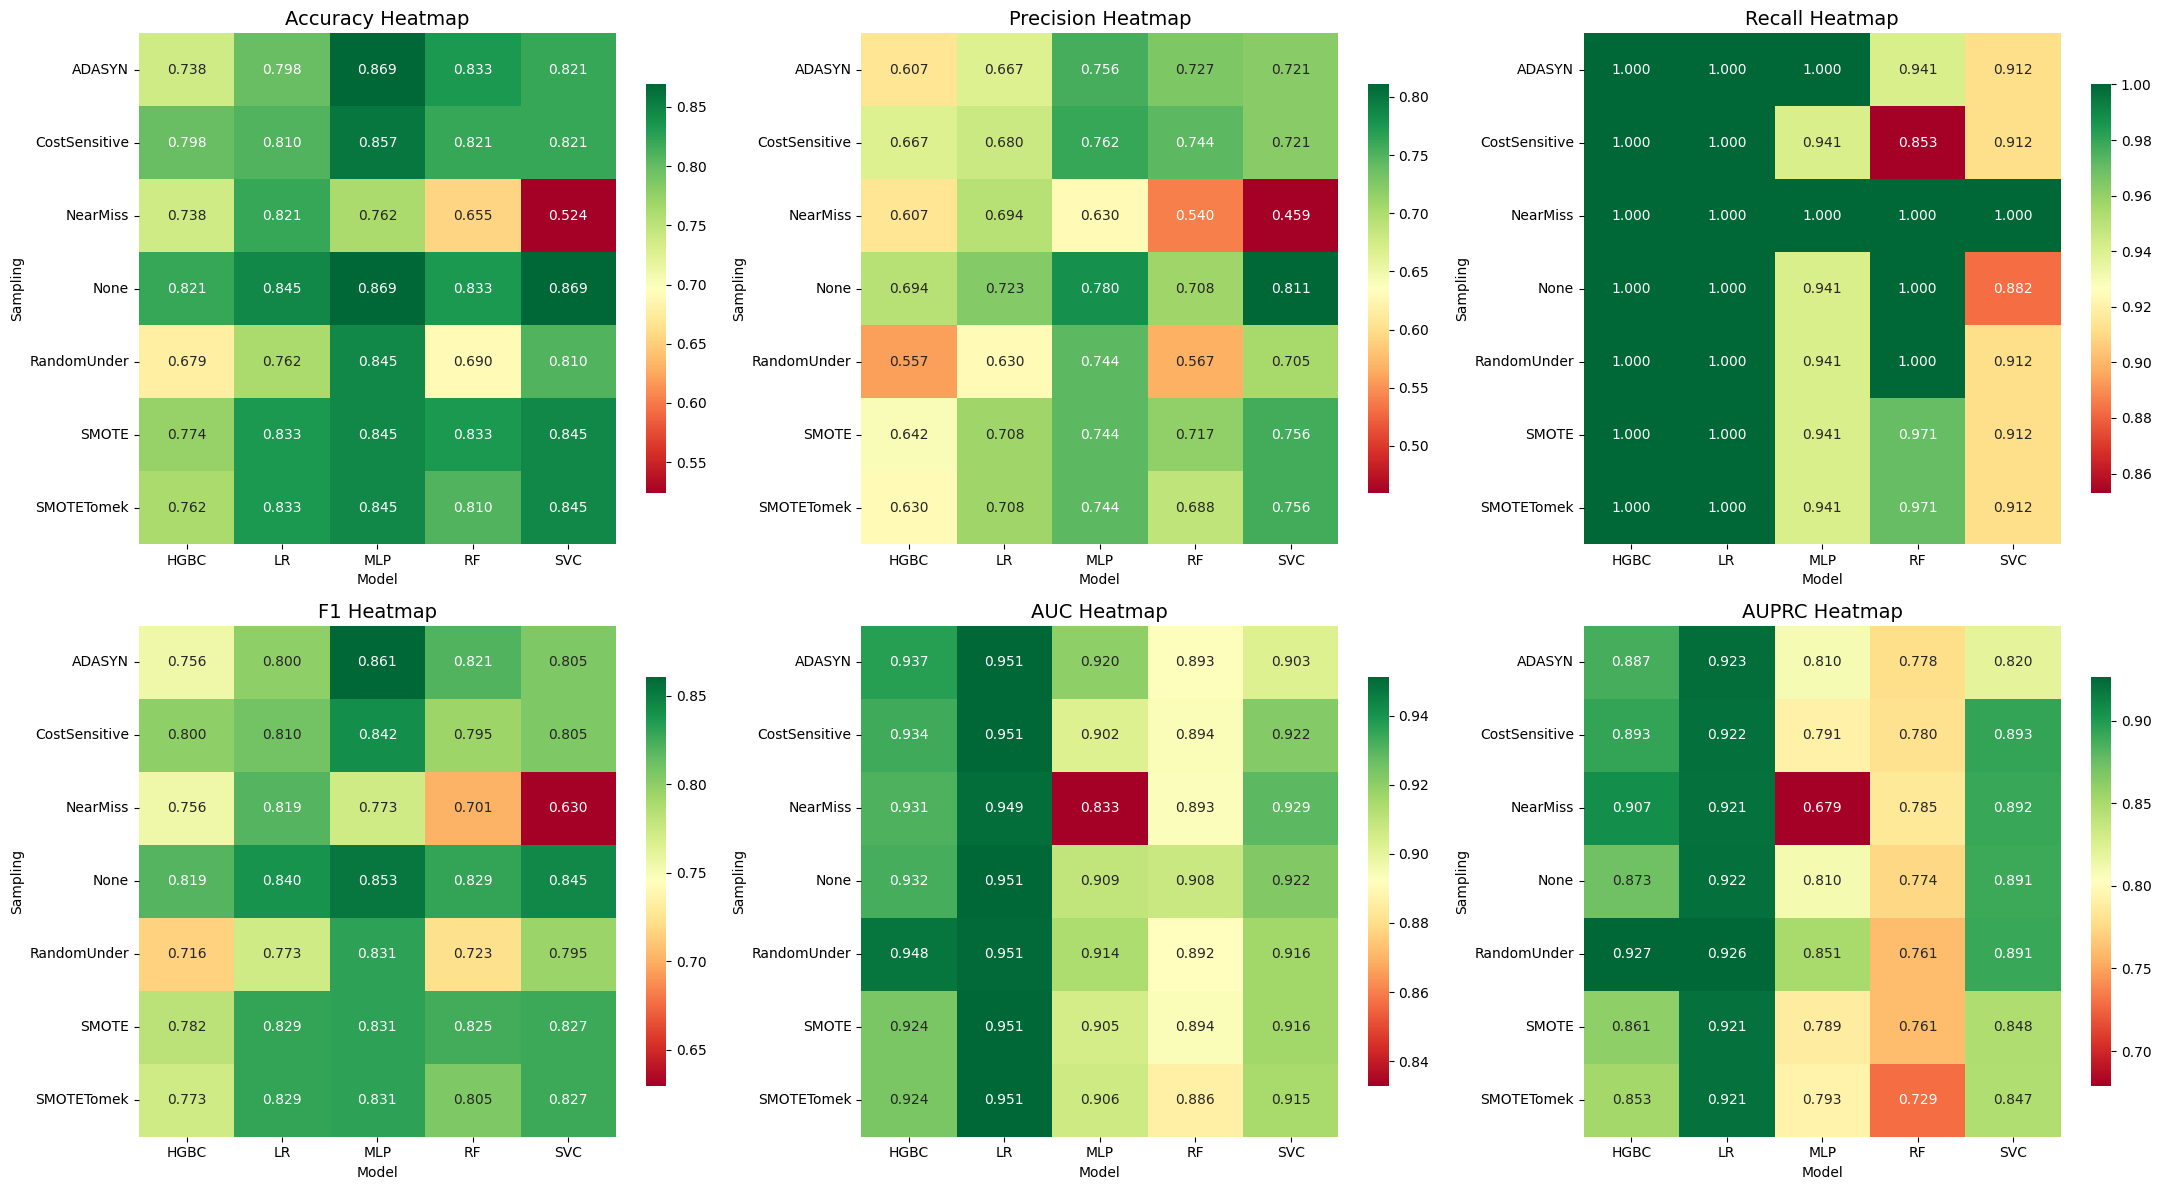

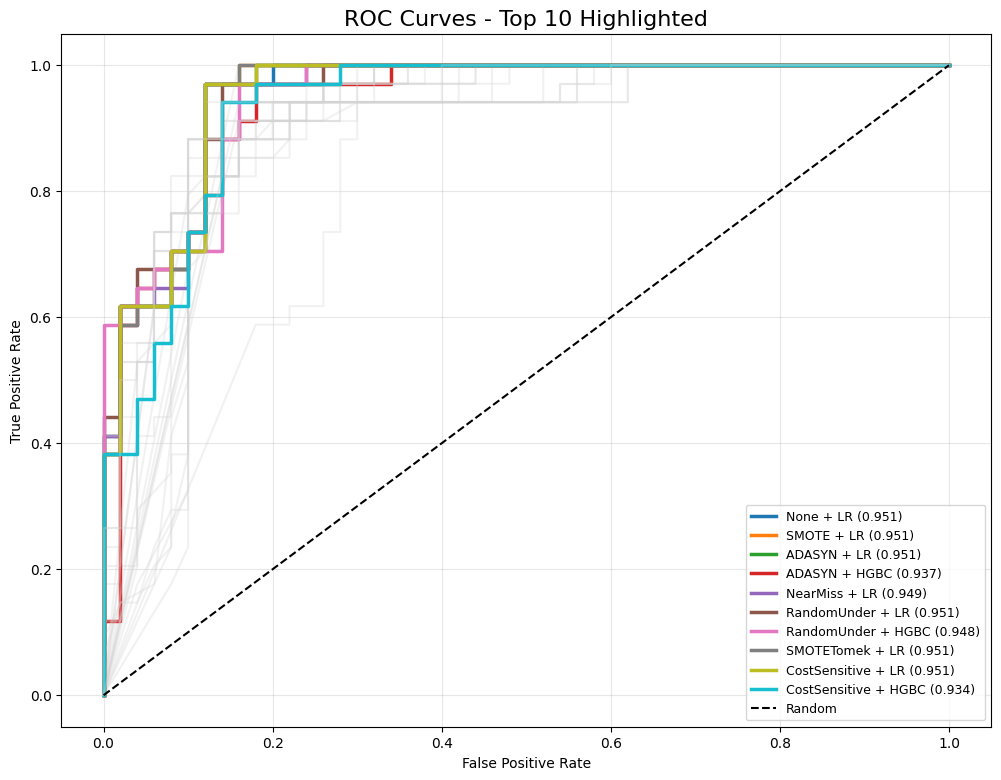

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             average_precision_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.utils import class_weight as cw

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss, RandomUnderSampler
from imblearn.combine import SMOTETomek

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os
import random
import numpy as np
import tensorflow as tf

# ---- FULL GLOBAL REPRODUCIBILITY ----
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ------------------- 1. Load & Split Data -------------------
# (Keep your original loading block unchanged)
if 'examstress' not in locals():
    print("WARNING: 'examstress' dataframe not found. Please load your data.")
else:
    df = examstress
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    print(f"Dataset: {X.shape}, Labels: {np.bincount(y)}")

    X_train = X
    X_test = X_holdout_labeled
    y_train = y
    y_test = y_holdout_labeled

    scaler = StandardScaler()
    X_train_scaled_orig = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# ------------------- 2. MLP Builder -------------------
def build_mlp(input_dim):
    tf.random.set_seed(42)
    model = Sequential([
        Dense(100, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(50, activation='relu'),
        Dropout(0.3),
        Dense(25, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='binary_crossentropy',
                  metrics=['AUC'])
    return model

# ------------------- 3. Setup Strategies -------------------
samplers = {
    'None': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'NearMiss': NearMiss(version=1),
    'RandomUnder': RandomUnderSampler(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'CostSensitive': 'cost_sensitive'
}

models = {
    'LR': LogisticRegression(max_iter=1000),
    'RF': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'HGBC': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'MLP': 'keras_mlp'
}

results = []
roc_curves = {}
pr_curves = {}
conf_matrices = {}  # To store confusion matrices
es = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

# ------------------- 4. Main Training Loop -------------------
for samp_name, sampler in samplers.items():
    print(f"\n=== {samp_name} ===")
    
    # Resampling
    if sampler is None or sampler == 'cost_sensitive':
        X_res, y_res = X_train_scaled_orig.copy(), y_train.copy()
    else:
        try:
            X_res, y_res = sampler.fit_resample(X_train_scaled_orig, y_train)
            print(f"    Resampled -> {X_res.shape}")
        except Exception as e:
            print(f"    Skipping {samp_name}: {e}")
            continue

    for model_name, model in models.items():
        print(f"   → {model_name}", end="")

        try:
            cw_dict = None
            sample_w = None
            curr_class_weight = None

            if samp_name == 'CostSensitive':
                w_vals = cw.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
                cw_dict = {i: w_vals[i] for i in range(len(w_vals))}
                sample_w = cw.compute_sample_weight('balanced', y_res)
                curr_class_weight = 'balanced'

            # Train model
            if model_name == 'MLP':
                mlp = build_mlp(X_res.shape[1])
                mlp.fit(X_res, y_res, epochs=200, batch_size=64, verbose=0,
                        validation_split=0.2, callbacks=[es], class_weight=cw_dict)
                y_proba = mlp.predict(X_test_scaled, verbose=0).ravel()
                y_pred = (y_proba > 0.5).astype(int)
            else:
                if model_name == 'HGBC':
                    model.fit(X_res, y_res, sample_weight=sample_w)
                else:
                    if hasattr(model, 'class_weight'):
                        model.set_params(class_weight=curr_class_weight)
                    model.fit(X_res, y_res)

                y_proba = model.predict_proba(X_test_scaled)[:, 1]
                y_pred = model.predict(X_test_scaled)

            # Metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc_score = roc_auc_score(y_test, y_proba)
            auprc = average_precision_score(y_test, y_proba)

            # Classification Report & Confusion Matrix
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            cm = confusion_matrix(y_test, y_pred)

            key = f"{samp_name} + {model_name}"
            conf_matrices[key] = cm

            results.append({
                'Sampling': samp_name,
                'Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1': f1,
                'AUC': auc_score,
                'AUPRC': auprc
            })

            fpr, tpr, _ = roc_curve(y_test, y_proba)
            prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
            roc_curves[key] = (fpr, tpr, auc_score)
            pr_curves[key] = (rec_c, prec_c, auprc)

            print(f" | Acc={acc:.3f} F1={f1:.3f} AUC={auc_score:.3f}")

            # Print confusion matrix in console
            print(f"\n     Confusion Matrix [{key}]")
            print(cm)
            print("     TN  FP")
            print("     FN  TP\n")

        except Exception as e:
            print(f" FAILED: {e}")
            conf_matrices[f"{samp_name} + {model_name}"] = np.array([[0,0],[0,0]])

# ------------------- 5. Results Summary -------------------
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("TOP 10 MODELS BY F1 SCORE")
print("="*80)
top10 = df_results.sort_values('F1', ascending=False).head(10)
print(top10[['Sampling', 'Model', 'F1', 'AUC', 'Recall', 'Precision']])

# ------------------- 6. Big Confusion Matrix Grid -------------------
fig, axes = plt.subplots(7, 6, figsize=(24, 26))
axes = axes.flatten()

for idx, (key, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                square=True, linewidths=1, linecolor='black',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                ax=axes[idx])
    axes[idx].set_title(key, fontsize=11, pad=10)

# Hide empty subplots if any
for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices - All Sampling + Model Combinations', fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("all_confusion_matrices_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------- 7. Heatmaps (same as before) -------------------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'AUPRC']
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    pivot = df_results.pivot_table(values=metric, index='Sampling', columns='Model')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[i],
                cbar_kws={"shrink": 0.8})
    axes[i].set_title(f'{metric} Heatmap', fontsize=14)

plt.tight_layout()
plt.savefig("performance_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------- 8. ROC Curves (Top 10 Highlighted) -------------------
plt.figure(figsize=(12, 9))
top_keys = df_results.sort_values('AUC', ascending=False).head(10).apply(
    lambda x: f"{x['Sampling']} + {x['Model']}", axis=1).tolist()

for label, (fpr, tpr, auc_sc) in roc_curves.items():
    if label in top_keys:
        plt.plot(fpr, tpr, label=f'{label} ({auc_sc:.3f})', lw=2.5)
    else:
        plt.plot(fpr, tpr, color='lightgray', alpha=0.3)

plt.plot([0,1],[0,1],'k--', label='Random')
plt.title('ROC Curves - Top 10 Highlighted', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.savefig("roc_curves_top10.png", dpi=300, bbox_inches='tight')
plt.show()